In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

current_path = os.getcwd()
directory = os.path.join(current_path) + "/../data/"
tot_dataframe = pd.DataFrame()
for root,dirs,files in os.walk(directory):
    for file in files:
       if file.endswith(".csv") and ("copy" in file):
          csv_path=directory+file
          data = pd.read_csv(csv_path)
          df = pd.DataFrame(data)
          copy_df = pd.concat([tot_dataframe,df])


input_size = copy_df['size'] * 2 # As I need to take as input a vector of SIZE elements of half
output_size = copy_df['size'] * 2 # The output is in float, hence SIZE elements of 32 bits
copy_df['mem_bytes'] = (copy_df['size'] * (2 ))  + copy_df['size'] * 2
copy_df['bandwidth_gbps'] = (copy_df['mem_bytes']) / (copy_df['time_us']*1000) #GB/s
copy_df["operator"] = "sc_copy"


/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/
/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/random_matrices_Uniform_custom_copy_4096_fp16_None.csv
   operator dtype        size   nrow  density    time_us   mem_bytes  \
0   sc_copy  fp16   100000000  10000      NaN    8726.95   400000000   
1   sc_copy  fp16   121000000  11000      NaN    7021.25   484000000   
2   sc_copy  fp16   144000000  12000      NaN   10619.83   576000000   
3   sc_copy  fp16   169000000  13000      NaN   12709.13   676000000   
4   sc_copy  fp16   196000000  14000      NaN   10512.79   784000000   
5   sc_copy  fp16   225000000  15000      NaN   15305.91   900000000   
6   sc_copy  fp16   256000000  16000      NaN   17378.16  1024000000   
7   sc_copy  fp16   289000000  17000      NaN   18830.02  1156000000   
8   sc_copy  fp16   324000000  18000      NaN   21050.74  1296000000   
9   sc_copy  fp16   361000000 

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_rows', 1000)


current_path = os.getcwd()
directory = os.path.join(current_path) + "/../data/Uniform/"
tot_dataframe = pd.DataFrame()
for root,dirs,files in os.walk(directory):
    for file in files:
       if file.endswith(".csv") and ("Uniform" in file):
          csv_path=directory+file
          data = pd.read_csv(csv_path)
          df = pd.DataFrame(data)
          tot_dataframe = pd.concat([tot_dataframe,df])

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4

tot_dataframe['bandwidth_gbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']*1000) #GB/s
tot_dataframe["density"] = ["%s" % x for x in tot_dataframe["density"]]
tot_dataframe = pd.concat([tot_dataframe,copy_df])



/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/Uniform/
/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/Uniform/random_matrices_Uniform_seg_scan_sc_128_fp16_0.01.csv
/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/Uniform/random_matrices_Uniform_seg_scan_sc_128_fp16_0.0001.csv
/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/Uniform/random_matrices_Uniform_seg_scan_sc_128_fp16_0.001.csv
                  operator dtype        size   nrow density    time_us  \
0     seg_scan_sc_128_0.01  fp16     1000000  10000    0.01    8119.48   
1     seg_scan_sc_128_0.01  fp16     1210000  11000    0.01    5984.93   
2     seg_scan_sc_128_0.01  fp16     1440000  12000    0.01    7013.94   
3     seg_scan_sc_128_0.01  fp16     1690000  13000    0.01    6732.42   
4     seg_scan_sc_128_0.01  fp16     1960000

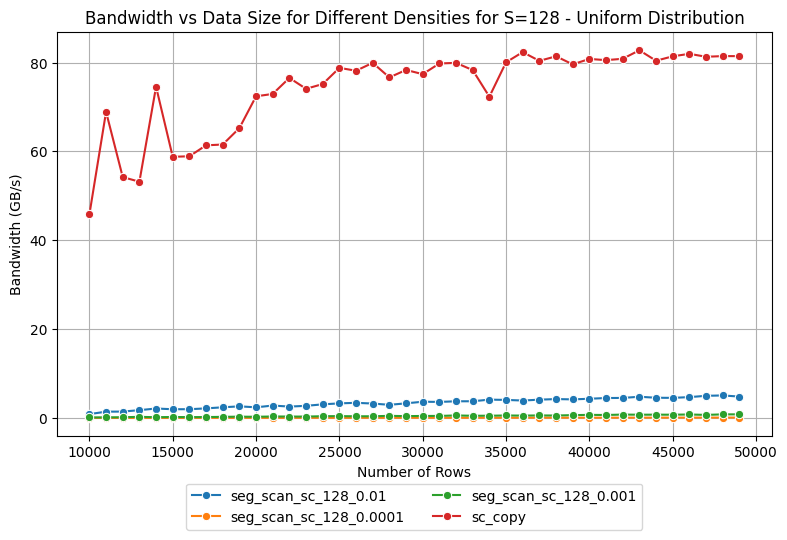

In [8]:

plt.figure(figsize=(8, 5))
sns.lineplot(x='nrow', y='bandwidth_gbps', hue='operator', data=tot_dataframe, marker='o')

plt.xlabel('Number of Rows')
plt.ylabel('Bandwidth (GB/s)')
plt.title('Bandwidth vs Data Size for Different Densities for S=128 - Uniform Distribution')
plt.tight_layout()

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.grid(True)
filename = "segmented_scan_uniform.pdf"
plt.savefig(filename, bbox_inches='tight')
plt.show()


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_rows', 1000)


current_path = os.getcwd()
directory = os.path.join(current_path) + "/../data/PowerLaw/"
tot_dataframe = pd.DataFrame()
for root,dirs,files in os.walk(directory):
    for file in files:
       if file.endswith(".csv") and ("PowerLaw" in file):
          csv_path=directory+file
          data = pd.read_csv(csv_path)
          df = pd.DataFrame(data)
          tot_dataframe = pd.concat([tot_dataframe,df])

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4

tot_dataframe['bandwidth_gbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']*1000) #GB/s
tot_dataframe["density"] = ["$%s$" % x for x in tot_dataframe["density"]]
tot_dataframe = pd.concat([tot_dataframe,copy_df])



/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/PowerLaw/
Empty DataFrame
Columns: []
Index: []
/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/PowerLaw/random_matrices_PowerLaw_seg_scan_sc_128_fp16_0.0001.csv
/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/PowerLaw/random_matrices_PowerLaw_seg_scan_sc_128_fp16_0.001.csv
/scratch/gsorrentino/tcuscan/tmp_newfig1_sparseSuiteAnalysis/pytorch-tcuscan/paper-plots/../data/PowerLaw/random_matrices_PowerLaw_seg_scan_sc_128_fp16_0.01.csv
                  operator dtype      size   nrow  density   time_us  \
0   seg_scan_sc_128_0.0001  fp16     10000  10000   0.0001   4060.94   
1   seg_scan_sc_128_0.0001  fp16     12100  11000   0.0001   2350.78   
2   seg_scan_sc_128_0.0001  fp16     14400  12000   0.0001   2884.54   
3   seg_scan_sc_128_0.0001  fp16     16900  13000   0.0001   3360.76   
4   seg_s

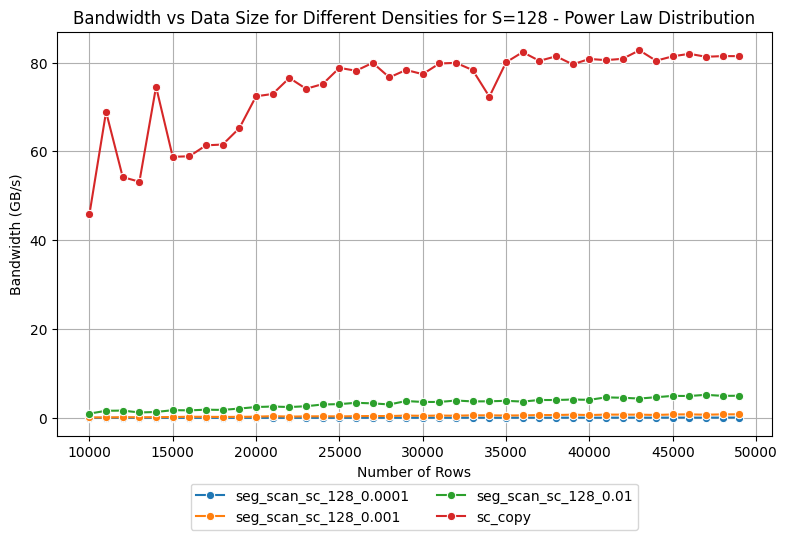

In [10]:

plt.figure(figsize=(8, 5))
sns.lineplot(x='nrow', y='bandwidth_gbps', hue='operator', data=tot_dataframe, marker='o')

plt.xlabel('Number of Rows')
plt.ylabel('Bandwidth (GB/s)')
plt.title('Bandwidth vs Data Size for Different Densities for S=128 - Power Law Distribution')
plt.tight_layout()

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.grid(True)
filename = "segmented_scan_powerlaw.pdf"
plt.savefig(filename, bbox_inches='tight')
plt.show()
